# Day 08. Exercise 05
# Clustering

## 0. Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import KMeans, DBSCAN
import seaborn as sns
from sklearn.metrics import silhouette_score
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import linkage, dendrogram


## 1. Preprocessing

1. Read the file [`regression.csv`](https://drive.google.com/file/d/1fzOPkuXoxLleOsvNVCT0m-LKxlid33ma/view?usp=sharing) to a dataframe.
2. Remove the `pageviews`, we will cluster the users only by the number of the commits and their average difference.

In [2]:
df = pd.read_csv("../data/regression.csv")
df = df.drop(columns="pageviews")
df.head()

,uid,num_commits,AVG(diff)
0,user_1,62,-64.400000
1,user_10,20,-74.800000
2,user_14,61,-159.000000
3,user_17,51,-61.600000
4,user_18,5,-5.666667


## 2. KMeans

1. Check the documentation about how this algorithm works.
2. Use this algorithm to create clusters, use `random_state=21` and `n_clusters=3`.
3. Visualize the data on a `scatter plot`.
4. Try different values of `n_clusters` and see how your plot will change.
5. Calculate the `silhouette_score` (check the docs about the metric).

In [3]:
X = df[['num_commits','AVG(diff)']]
kmeans = KMeans(n_clusters=3, random_state=21)
kmeans.fit(X)
print(kmeans.labels_)

[0 0 1 0 0 2 2 2 2 1 1 0 2 0 0 0 1 0 1 0 1 0 0 1 2 1 0 1 1]


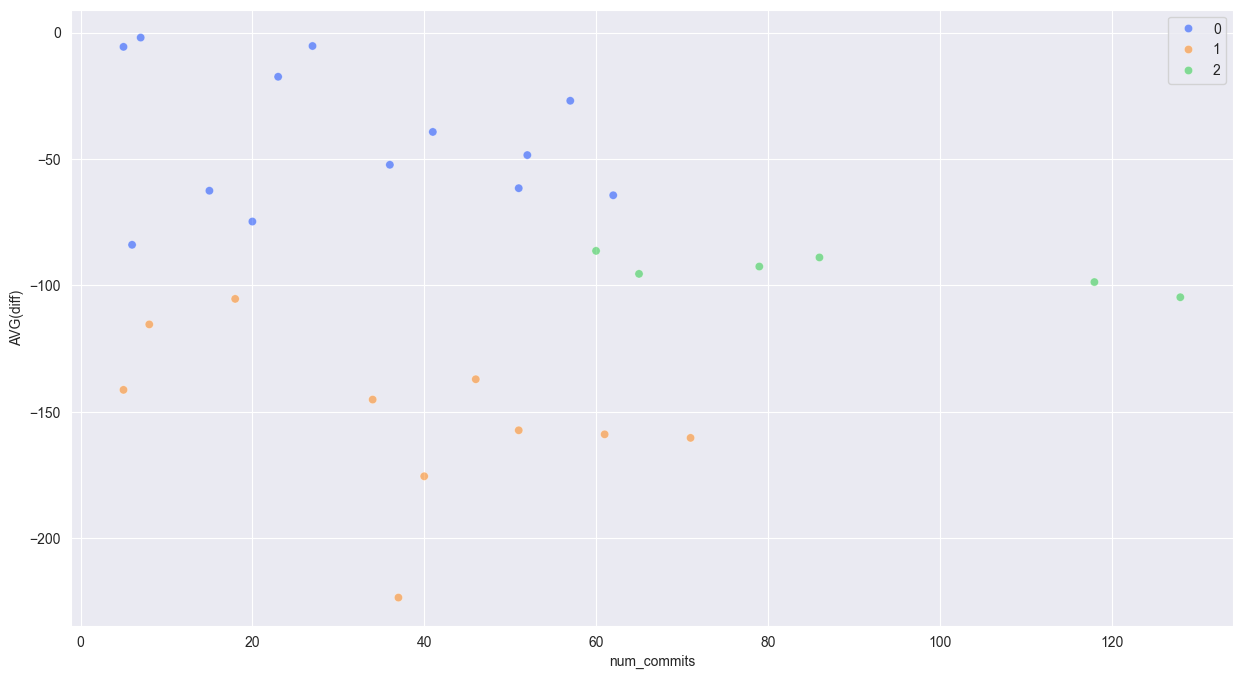

In [4]:
plt.figure(figsize=(15,8))
sns.scatterplot(x= df['num_commits'],y=df['AVG(diff)'] ,hue=kmeans.labels_,palette='bright', alpha=0.5)
plt.grid(True)
plt.show()

In [5]:
ss = silhouette_score(X, kmeans.labels_)
print(ss)

0.4454402135233297


## 3. DBSCAN

1. Check the documentation about how this algorithm works.
2. Use this algorithm to create clusters with `eps=20` and `min_samples=2`.
3. Visualize the data on a `scatter plot`.
4. Try different values of `eps` and `min_samples` and see how your plot will change.
5. Calculate the `silhouette_score` (check the docs about the metric).

In [6]:
dbscan = DBSCAN(eps=20, min_samples=2)
dbscan.fit(X)
print(dbscan.labels_)


[ 0  1  2  0  3  4  5  5  5  6  7  3  5  0  8  0  7 -1 -1  1 -1  0  8  2
  4 -1  1  6  2]


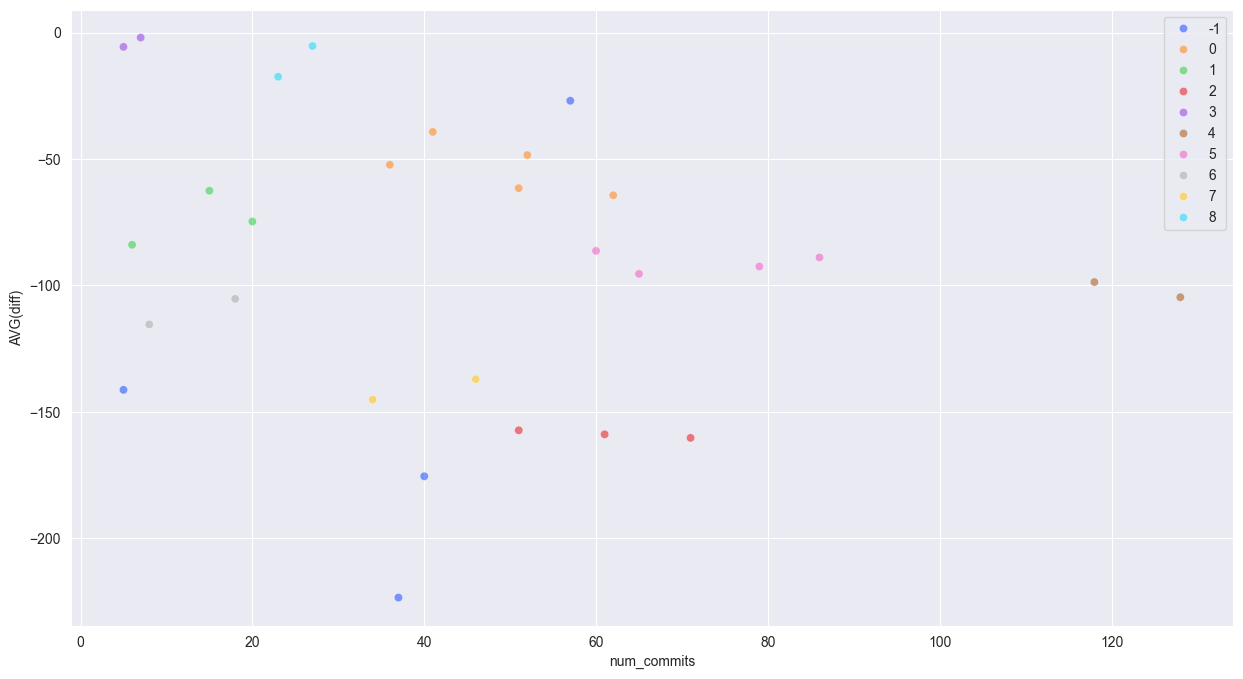

In [7]:
plt.figure(figsize=(15, 8))
sns.scatterplot(x=df['num_commits'], y=df['AVG(diff)'], hue=dbscan.labels_, palette='bright', alpha=0.5)
plt.grid(True)
plt.show()

In [8]:
ss = silhouette_score(X, dbscan.labels_)
print(ss)

0.38339641455696616


## 4. Hierarchical (AgglomerativeClustering)

1. Use this algorithm to create clusters with `n_clusters=5`.
2. Visualize the data on a `scatter plot`.
3. Try different values of `n_clusters` and see how your plot will change.
4. Calculate the `silhouette_score`.
5. Visualize the `dendrogram`.

In [9]:
aggClus= AgglomerativeClustering(n_clusters=5,linkage='ward')

In [10]:
aggClus.fit(X)
print(aggClus.labels_)


[2 3 0 2 4 1 1 1 1 3 0 4 1 2 4 2 0 2 3 3 0 2 4 0 1 0 3 3 0]


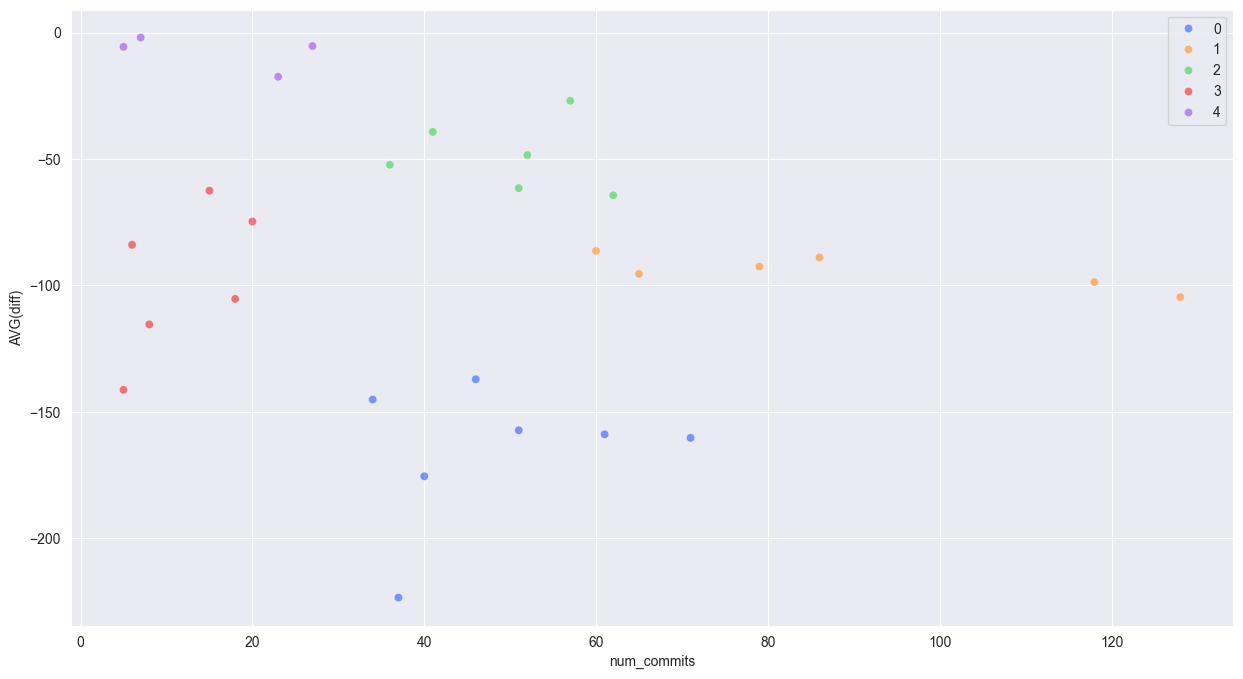

In [11]:
plt.figure(figsize=(15, 8))
sns.scatterplot(x=df['num_commits'], y=df['AVG(diff)'], hue=aggClus.labels_, palette='bright', alpha=0.5)
plt.grid(True)
plt.show()

In [12]:
ss = silhouette_score(X, aggClus.labels_)
print(ss)

0.46383015199381467


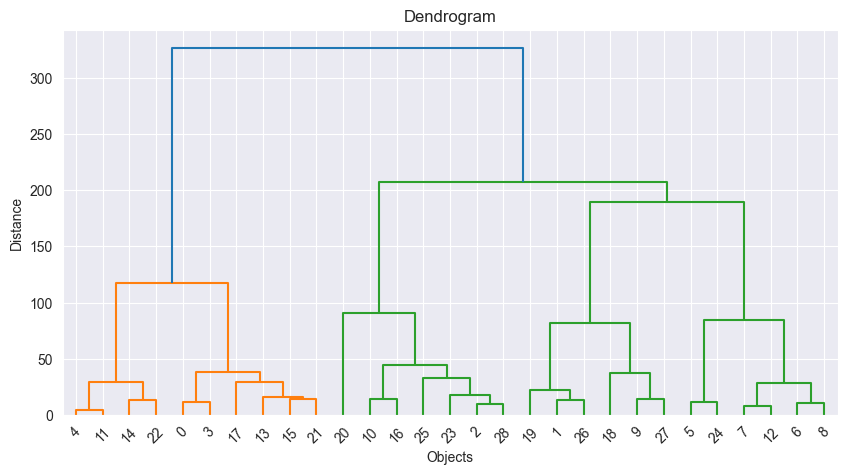

In [13]:
Z = linkage(X, method='ward') 
plt.figure(figsize=(10, 5))
dendrogram(Z)
plt.title('Dendrogram')
plt.xlabel('Objects')
plt.ylabel('Distance')
plt.show()

## 5. Function

Write a function that:
1. Takes as arguments: model class of clustering, its parameters, the name of the parameter for optimization, the range of the parameter values to try.
2. Tries different values from the given parameter range and calculates the `silhouette_score` for each value from the range.
3. Finds out the best value for the parameter in the range.
4. Returns two subplots:


- - the first shows how the `silhouette_score` changes depending on the value of the parameter,
- - the second visualizes the data on a `scatter plot` using the clustering model with the best value of the parameter.

In [14]:
def optimize_and_plot_clustering(model_class, fixed_params, param_name, param_range, X):
    if hasattr(X, 'values'):
        X_array = X.values
    else:
        X_array = np.array(X)
    
    scores = []
    valid_params = []
    
    for value in param_range:
        current_params = fixed_params.copy()
        current_params[param_name] = value
        
        try:
            model = model_class(**current_params)
            labels = model.fit_predict(X_array)
            unique_labels = np.unique(labels)
            
            unique_real = unique_labels[unique_labels != -1]
            
            if len(unique_real) > 1 and len(unique_real) < len(X_array):
                mask = labels != -1
                if mask.sum() > 1 and len(np.unique(labels[mask])) > 1:
                    score = silhouette_score(X_array[mask], labels[mask])
                    scores.append(score)
                    valid_params.append(value)
            else:
                pass
                
        except Exception as e:
            print(f"Ошибка при параметре {param_name}={value}: {e}")
            continue

    if not scores:
        print("Не удалось рассчитать оценки для заданного диапазона.")
        return None, None

    best_idx = np.argmax(scores)
    best_param = valid_params[best_idx]
    best_score = scores[best_idx]
    
    print(f"Оптимальное значение {param_name}: {best_param} (score: {best_score:.4f})")

    best_params = fixed_params.copy()
    best_params[param_name] = best_param
    best_model = model_class(**best_params)
    best_labels = best_model.fit_predict(X_array)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    ax1.plot(valid_params, scores, marker='o', linestyle='-')
    ax1.set_title(f'Зависимость Silhouette Score от {param_name}')
    ax1.set_xlabel(param_name)
    ax1.set_ylabel('Silhouette Score')
    ax1.axvline(x=best_param, color='r', linestyle='--', label=f'Лучшее значение: {best_param}')
    ax1.legend()
    ax1.grid(True)
    
    if X_array.shape[1] > 2:
        print("Предупреждение: Данные имеют размерность > 2. Для визуализации взяты первые 2 признака.")
    
    scatter = ax2.scatter(X_array[:, 0], X_array[:, 1], c=best_labels, cmap='viridis', alpha=0.6)
    ax2.set_title(f'Результат кластеризации ({param_name}={best_param})')
    ax2.set_xlabel('Признак 1')
    ax2.set_ylabel('Признак 2')
    
    plt.colorbar(scatter, ax=ax2, label='Кластер')
    
    plt.tight_layout()
    
    return best_param, fig

Оптимальное значение n_clusters: 8 (score: 0.4864)


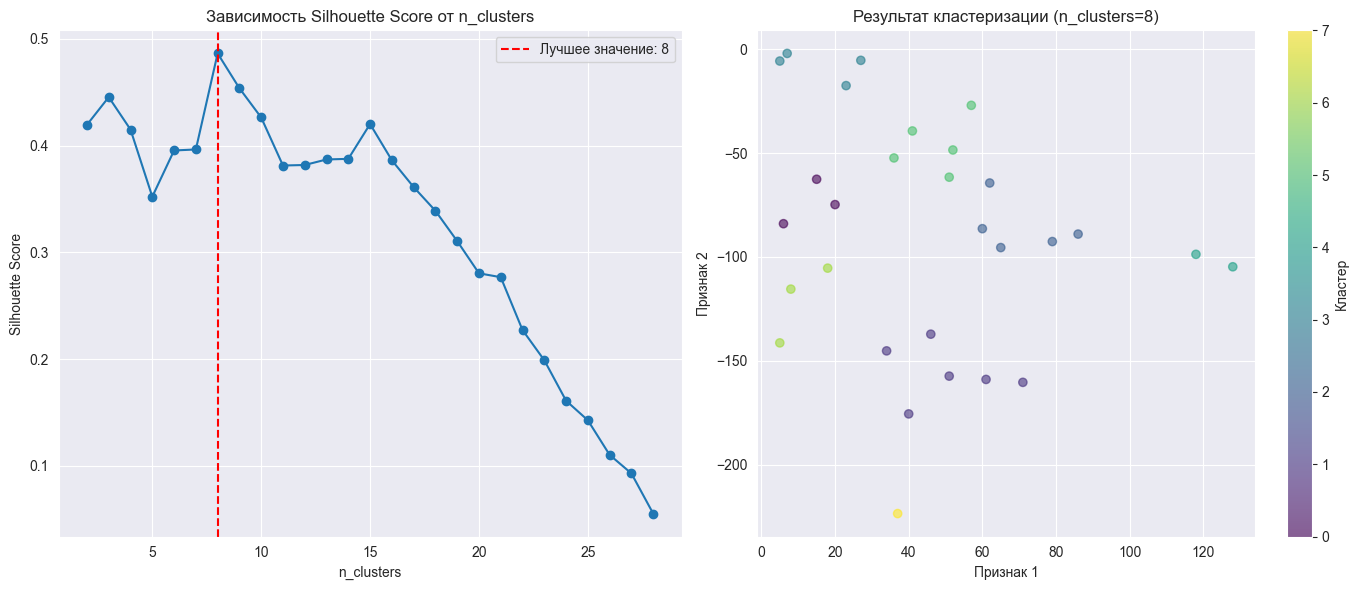

In [15]:
fix_params = {'random_state': 21}
best_param, figure= optimize_and_plot_clustering(KMeans,fix_params,'n_clusters', range(1,30),X)
plt.show()